# 055. 양방향 LSTM을 이용한 개체명 인식

- Named Entity Recognition using Bi-LSTM


- 개체명 인식은 챗봇 등에서 필요로 하는 주요 전처리 작업  (질문 문장의 어절을 일반화시키는 과정에서 개체명(Named Entity) 인식 사전을 활용)


- 도메인 또는 목적에 특화되도록 개체명 인식을 정확하게 하는 방법 중 하나는 기존에 공개된 개체명 인식기를 사용하는 것이 아니라, 직접 목적에 맞는 데이터를 준비하여 기계를 훈련시켜 모델을 만드는 방법임  


### BIO
- B (Begin) - 개체명이 시작되는 부분  
- I (Inside) - 개체명의 내부 부분  
- O (Outside) - 개체명이 아닌 부분


- 각 개체가 어떤 종류인지도 함께 태깅  
```
해 B-movie  
리 I-movie  
포 I-movie  
터 I-movie  
보 O  
러 O  
메 B-theater  
가 I-theater  
박 I-theater  
스 I-theater  
가 O  
자 O  
```



### CoNLL2003 dataset 이용

- CoNLL -  the Conference on Natural Language Learning  


- https://raw.githubusercontent.com/Franck-Dernoncourt/NeuroNER/master/neuroner/data/conll2003/en/train.txt  에서 download  





CoNLL (Conference on Natural Language Learning)는 자연어 처리 분야의 학회로, 매년 열리며 자연어 처리 관련 최신 연구와 발전을 공유하는 자리입니다. CoNLL에서 제공하는 데이터셋은 특히 언어 학습과 관련된 연구에 널리 사용됩니다.

여기서 언급된 'https://raw.githubusercontent.com/Franck-Dernoncourt/NeuroNER/master/neuroner/data/conll2003/en/train.txt'는 CoNLL 2003에서 사용된 텍스트 데이터셋의 일부로, 특정 단어에 대한 정보를 포함하는 4개의 열로 구성됩니다. 이 데이터셋의 구조는 다음과 같습니다:

- `[word][pos Tagging][chunk tagging][named entity tagging]` 의 4 column 형식으로 구성  

1. **단어(Word)**: 문장을 구성하는 각 단어입니다.
2. **POS Tagging**: 각 단어의 품사를 나타냅니다. 예를 들어, 명사, 동사, 형용사 등입니다.
3. **Chunk Tagging**: 문장 내에서 단어의 구문적 그룹(청크)를 나타냅니다. 예를 들어, 명사구(NP)나 동사구(VP) 등입니다.
4. **Named Entity Tagging**: 각 단어가 특정 명명된 개체(인명, 지명, 기관명 등)에 해당하는지와 그 유형을 나타냅니다. 예를 들어, 'LOC'는 위치(지명), 'ORG'는 기관, 'PER'는 사람, 'MISC'는 기타를 의미합니다. 또한, 'B'는 개체명이 시작하는 부분, 'I'는 개체명 내부를, 'O'는 개체명이 아닌 부분을 나타냅니다.
    - NE(Named Entity) tagging :   
        LOC - location,   
        ORG - organization,  
        PER - person,   
        MISC - miscellaneous,   
        B - phrase 시작,   
        I - inside phrase,   
        O - phrase 의 일부가 아님

"The European Commission said on Thursday it disagreed with German advice to consumers to shun" 의 경우, 'European'은 'ORG' (기관명) 유형의 개체명으로 시작하는 부분이고, 'Commission'은 같은 개체명의 내부 부분을 나타냅니다. 나머지 단어들은 개체명이 아니며('O'), 각각의 품사와 청크 정보를 가지고 있습니다.
```
The DT B-NP O                             # 개체명 아님               
European NNP I-NP B-ORG            # ORG type phrase 시작
Commission NNP I-NP I-ORG         # phrase 에 속함 - ORG
said VBD B-VP O                           # 개체명 아님
on IN B-PP O
Thursday NNP B-NP O
it PRP B-NP O
disagreed VBD B-VP O
with IN B-PP O
German JJ B-NP B-MISC                # MISC type phrase 시작
advice NN I-NP O
to TO B-PP O
consumers NNS B-NP O
to TO B-VP O
shun VB I-VP O
```

## Dataset download 및 전처리

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Embedding, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

- `-DOCSTART- -X- -X- O` 로 file 시작 --> 문서 시작 line
-  문장 사이는 empty line 으로 구분

In [2]:
file_path = tf.keras.utils.get_file("train.txt",
    "https://raw.githubusercontent.com/Franck-Dernoncourt/NeuroNER/master/neuroner/data/conll2003/en/train.txt")

In [3]:
# 파일에서 처음 20줄 읽기
for line in open(file_path, 'r').readlines()[:20]:
    print(repr(line))    # 각 줄을 문자 그대로(repr) 출력

'-DOCSTART- -X- -X- O\n'
'\n'
'EU NNP B-NP B-ORG\n'
'rejects VBZ B-VP O\n'
'German JJ B-NP B-MISC\n'
'call NN I-NP O\n'
'to TO B-VP O\n'
'boycott VB I-VP O\n'
'British JJ B-NP B-MISC\n'
'lamb NN I-NP O\n'
'. . O O\n'
'\n'
'Peter NNP B-NP B-PER\n'
'Blackburn NNP I-NP I-PER\n'
'\n'
'BRUSSELS NNP B-NP B-LOC\n'
'1996-08-22 CD I-NP O\n'
'\n'
'The DT B-NP O\n'
'European NNP I-NP B-ORG\n'


In [4]:
import re

tagged_sentences = []  # 태그된 문장들을 저장할 리스트
sentence = []          # 개별 문장을 구성할 단어와 태그를 저장할 리스트

# 파일을 읽어서 각 줄 처리
for line in open(file_path, 'r'):
    # 빈 줄, 문서 시작 라인, 줄바꿈은 건너뜀
    if len(line) == 0 or line.startswith('-DOCSTART') or line[0] == "\n":
        if len(sentence) > 0:
            tagged_sentences.append(sentence)  # 기존 문장을 tagged_sentences에 추가
            sentence = []                      # 새 문장 시작을 위해 sentence 초기화
        continue

    # 각 줄에서 단어, POS 태그, 청크 태그, 개체명 태그 추출
    word, pos_tag, chunk_tag, ner = line.split(' ')  # 공백으로 속성 분리
    ner = re.sub('\n', '', ner)  # 개체명 태그에서 줄바꿈 문자 제거
    word = word.lower()  # 단어를 소문자로 변환
    sentence.append((word, ner))  # 단어와 개체명 태그를 sentence에 추가

# 마지막 문장 처리
if len(sentence) > 0:
    tagged_sentences.append(sentence)

In [5]:
print("전체 샘플 개수: ", len(tagged_sentences)) # 전체 샘플의 개수 출력
print()
tagged_sentences[:3]

전체 샘플 개수:  14041



[[('eu', 'B-ORG'),
  ('rejects', 'O'),
  ('german', 'B-MISC'),
  ('call', 'O'),
  ('to', 'O'),
  ('boycott', 'O'),
  ('british', 'B-MISC'),
  ('lamb', 'O'),
  ('.', 'O')],
 [('peter', 'B-PER'), ('blackburn', 'I-PER')],
 [('brussels', 'B-LOC'), ('1996-08-22', 'O')]]

## N to N model

### input, label data 작성을 위해 단어와 tag 를 분리

In [6]:
inputs, labels = [], []  #   입력(단어)과 레이블(태그)을 저장할 리스트

# 태그된 문장들을 순회하면서 단어와 태그 분리
for pairs in tagged_sentences:
    words, tags = zip(*pairs)      # 각 문장에서 단어와 태그 분리
    inputs.append(list(words))   # 단어들을 inputs 리스트에 추가
    labels.append(list(tags))      # 태그들을 labels 리스트에 추가

# 첫 번째 시퀀스의 입력과 레이블 출력
print(inputs[0])  # 첫 번째 문장의 단어들
print(labels[0])  # 첫 번째 문장의 개체명 태그들

['eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb', '.']
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


샘플의 최대 길이 : 113
샘플의 평균 길이 : 14.501887


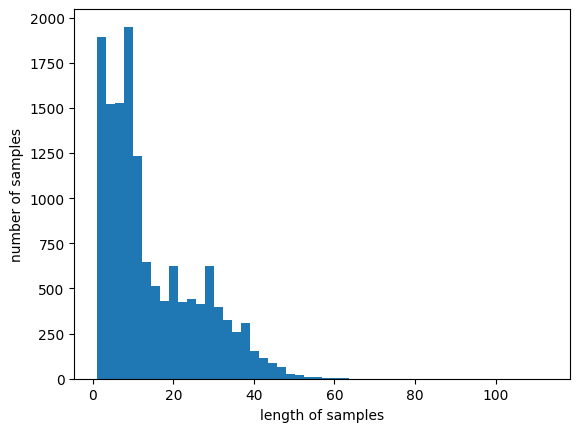

In [7]:
print('샘플의 최대 길이 : {}'.format(max([len(w) for w in inputs])))
print('샘플의 평균 길이 : {:4f}'.format(np.mean([len(w) for w in inputs])))
plt.hist([len(s) for s in inputs], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

**sample 들의 길이가 대체적으로 0-40의 길이를 가지며, 특히 0-20의 길이를 가진 샘플이 상당한 비율을 차지**

**keras 는 fixed size sequence 만 handling 가능하므로 max sequence length 를 60 으로 정함**

In [8]:
MAX_LENGTH = 60

### 전체 word 수 check

In [9]:
# Tokenizer 객체 생성 및 inputs에 대한 토큰화 수행
tokenizer = Tokenizer()
tokenizer.fit_on_texts(inputs)

# 생성된 단어 인덱스 사전의 크기 출력
print(len(tokenizer.word_index))

21009


전체 token 갯수가 21009 개 이므로 상위 4000 개로 제한하여 vocabulary 재작성하고,  문장 데이터에 대해서는 entity_tokenizer를, 레이블에 해당되는 개체명 태깅 정보에 대해서는 tag_tokenizer를 작성

In [10]:
MAX_WORDS = 4000

### train, test split

In [11]:
from sklearn.model_selection import train_test_split

# 입력 데이터와 태그 데이터를 훈련 세트와 테스트 세트로 분리
train_sentences, test_sentences, train_tags, test_tags =  \
                train_test_split(inputs, labels, test_size=0.2)

# 각 세트의 크기 출력
len(train_sentences), len(test_sentences), len(train_tags), len(test_tags)

(11232, 2809, 11232, 2809)

### word vocabulary 작성

- train data 는 validation set 을 볼 수 없으므로, entity tokenizer는 train_sentences 에 대해서만 tokenize 하고, tag tokenizer 는 전체 labels 에 대해 tokenize 한다.

In [12]:
MAX_WORDS = 10000  # 단어 집합의 최대 크기 설정

# 문장에 대한 Tokenizer 객체 생성 및 훈련
entity_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
entity_tokenizer.fit_on_texts(train_sentences)

# 개체명 태그에 대한 Tokenizer 객체 생성 및 훈련
tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(labels)

# 단어 집합의 크기와 개체명 태깅 정보 집합의 크기 계산
vocab_size = entity_tokenizer.num_words + 1      # 단어 집합의 크기
tag_size = len(tag_tokenizer.word_index) + 1     # 개체명 태그 집합의 크기

# 각 집합의 크기 출력
print('단어 집합의 크기 : {}'.format(vocab_size))
print('개체명 태깅 정보 집합의 크기 : {}'.format(tag_size))

단어 집합의 크기 : 10001
개체명 태깅 정보 집합의 크기 : 10


In [13]:
print(tag_tokenizer.word_index)

{'o': 1, 'b-loc': 2, 'b-per': 3, 'b-org': 4, 'i-per': 5, 'i-org': 6, 'b-misc': 7, 'i-loc': 8, 'i-misc': 9}


### pad sequences  

- sentence 와 tag 를 sequence 로 변환  

In [14]:
# 훈련 데이터셋의 문장을 시퀀스로 변환
X_train = entity_tokenizer.texts_to_sequences(train_sentences)

# 훈련 데이터셋의 태그를 시퀀스로 변환
y_train = tag_tokenizer.texts_to_sequences(train_tags)

# 테스트 데이터셋의 문장을 시퀀스로 변환
X_test = entity_tokenizer.texts_to_sequences(test_sentences)

# 테스트 데이터셋의 태그를 시퀀스로 변환
y_test = tag_tokenizer.texts_to_sequences(test_tags)

# 변환된 훈련 및 테스트 데이터셋의 길이 출력
len(X_train), len(y_train), len(X_test), len(y_test)

(11232, 11232, 2809, 2809)

In [15]:
for i in range(5):
    print((train_sentences[i]))
    print((train_tags[i]))
    print(X_train[i])
    print(y_train[i])
    print()

['that', 'is', 'to', 'end', 'the', 'state', 'of', 'hostility', ',', '"', 'thursday', "'s", 'overseas', 'edition', 'of', 'the', 'people', "'s", 'daily', 'quoted', 'tang', 'as', 'saying', '.']
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'O', 'B-PER', 'O', 'O', 'O']
[26, 30, 7, 258, 2, 108, 5, 4871, 4, 12, 67, 15, 2468, 3910, 5, 2, 94, 15, 585, 488, 3911, 32, 287, 3]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 6, 6, 1, 3, 1, 1, 1]

['in', 'san', 'diego', ',', 'joey', 'hamilton', 'allowed', 'two', 'hits', 'over', 'seven', 'innings', 'and', 'rickey', 'henderson', 'hit', 'his', 'major', 'league-record', '69th', 'leadoff', 'homer', 'as', 'the', 'san', 'diego', 'padres', 'defeated', 'the', 'philadelphia', 'phillies', '7-1', 'for', 'their', 'fifth', 'win', 'in', 'six', 'games', '.']
['O', 'B-LOC', 'I-LOC', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'

In [16]:
MAX_LENGTH = 100  # 최대 시퀀스 길이 설정

# 훈련 데이터셋의 문장 시퀀스 패딩
X_train_padded = pad_sequences(X_train, maxlen=MAX_LENGTH, padding='post')

# 테스트 데이터셋의 문장 시퀀스 패딩
X_test_padded = pad_sequences(X_test, maxlen=MAX_LENGTH, padding='post')

# 훈련 데이터셋의 태그 시퀀스 패딩
y_train_padded = pad_sequences(y_train, maxlen=MAX_LENGTH, padding='post')

# 테스트 데이터셋의 태그 시퀀스 패딩
y_test_padded = pad_sequences(y_test, maxlen=MAX_LENGTH, padding='post')

# 패딩된 훈련 및 테스트 데이터셋의 첫 번째 시퀀스 출력
print(X_train_padded[0])
print(y_train_padded[0])
print()
print(X_test_padded[0])
print(y_test_padded[0])

[  26   30    7  258    2  108    5 4871    4   12   67   15 2468 3910
    5    2   94   15  585  488 3911   32  287    3    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 4 6 6 1 3 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

[1335 3517   17 4552   17    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
  

In [17]:
# 훈련 데이터셋의 태그 시퀀스를 원-핫 인코딩으로 변환
y_train_onehot = to_categorical(y_train_padded, num_classes=tag_size)

# 테스트 데이터셋의 태그 시퀀스를 원-핫 인코딩으로 변환
y_test_onehot = to_categorical(y_test_padded, num_classes=tag_size)

### many-to-many model 이므로 return_sequences=True 로 설정

In [18]:
model = Sequential()
model.add(Embedding(vocab_size, 128))  # 임베딩 레이어: 단어를 128차원의 벡터로 매핑
model.add(Bidirectional(LSTM(256, return_sequences=True)))  # 256개의 유닛을 가진 양방행 LSTM
model.add(Dense(tag_size, activation='softmax'))  # 각 태그에 대한 확률 분포 출력

model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 128)         1280128   
                                                                 
 bidirectional (Bidirection  (None, None, 512)         788480    
 al)                                                             
                                                                 
 dense (Dense)               (None, None, 10)          5130      
                                                                 
Total params: 2073738 (7.91 MB)
Trainable params: 2073738 (7.91 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
model.fit(X_train_padded, y_train_onehot , batch_size=128, epochs=10,
              validation_data=(X_test_padded, y_test_onehot))

Epoch 1/10
88/88 [==============================] - 23s 203ms/step - loss: 0.2790 - accuracy: 0.9419 - val_loss: 0.1206 - val_accuracy: 0.9752
Epoch 2/10
88/88 [==============================] - 6s 71ms/step - loss: 0.1116 - accuracy: 0.9753 - val_loss: 0.0927 - val_accuracy: 0.9764
Epoch 3/10
88/88 [==============================] - 6s 66ms/step - loss: 0.0757 - accuracy: 0.9779 - val_loss: 0.0631 - val_accuracy: 0.9814
Epoch 4/10
88/88 [==============================] - 4s 50ms/step - loss: 0.0547 - accuracy: 0.9831 - val_loss: 0.0535 - val_accuracy: 0.9839
Epoch 5/10
88/88 [==============================] - 4s 46ms/step - loss: 0.0450 - accuracy: 0.9863 - val_loss: 0.0485 - val_accuracy: 0.9863
Epoch 6/10
88/88 [==============================] - 4s 50ms/step - loss: 0.0374 - accuracy: 0.9892 - val_loss: 0.0410 - val_accuracy: 0.9887
Epoch 7/10
88/88 [==============================] - 3s 39ms/step - loss: 0.0285 - accuracy: 0.9922 - val_loss: 0.0345 - val_accuracy: 0.9910
Epoch 8/10


In [20]:
scores = model.evaluate(X_test_padded, y_test_onehot, verbose=0)
print(f"{model.metrics_names[1]}: {scores[1] * 100}")

accuracy: 99.34353828430176


### test inference

In [21]:
test_sample = ["EU gave German call to take British people"]

# 테스트 샘플 문장을 토큰화
test_sample_tokenized = entity_tokenizer.texts_to_sequences(test_sample)
print(test_sample_tokenized)

# 토큰화된 테스트 샘플 문장을 패딩
test_sample_padded = pad_sequences(test_sample_tokenized, maxlen=MAX_LENGTH, padding='post')
print(test_sample_padded)

[[855, 424, 194, 668, 7, 291, 214, 94]]
[[855 424 194 668   7 291 214  94   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]]


In [22]:
# 단어 인덱스를 단어로 변환하기 위한 사전 생성
index2word = entity_tokenizer.index_word

# 태그 인덱스를 태그로 변환하기 위한 사전 생성
index2tag = tag_tokenizer.index_word

In [23]:
# 모델을 사용하여 테스트 샘플 문장에 대한 예측 수행
y_predicted = model.predict(test_sample_padded)

# 예측된 결과에서 가장 확률이 높은 태그의 인덱스 추출
y_pred = y_predicted.argmax(axis=-1)

# 예측된 태그 인덱스 출력
y_pred

1/1 [==============================] - 1s 678ms/step


array([[4, 1, 7, 1, 1, 1, 7, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [24]:
# 모델이 예측한 태그와 함께 테스트 샘플 문장의 단어 출력
for i in range(len(test_sample_tokenized)):
    for word, tag in zip([index2word.get(x, '?') for x in test_sample_tokenized[i]], [index2tag.get(y, '?') for y in y_pred[i]]):
        if word != '<OOV>' and word != '?' and tag != '?':
            print(f'{word} :  {tag.upper()}')

eu :  B-ORG
gave :  O
german :  B-MISC
call :  O
to :  O
take :  O
british :  B-MISC
people :  O
